In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
from scipy import optimize
import os, re, sys, warnings
warnings.filterwarnings("ignore")

def fit(x, dense, dilute, shift, width):
    return 0.5 * (dense + dilute) - 0.5 * (dense - dilute) * np.tanh((2 * (x - shift)) / width)

def conc_analytic(norm_den,x_range):    
    try:
        popt_dilute, pcov_dilute = optimize.curve_fit(fit, x_range, np.log10(norm_den), p0 = [-0.5, -4, 30, 20])
    except RuntimeError:
        popt_dilute = np.zeros(4)
        pcov_dilute = np.zeros((4, 4))
    perr_dilute = np.sqrt(np.diag(pcov_dilute))

    dense_conc = 10**popt_dilute[0]
    dilute_conc = 10**popt_dilute[1]
    interface_mid = popt_dilute[2]
    interface_width = popt_dilute[3]
    
    return(dilute_conc,dense_conc,interface_mid,interface_width)

In [2]:
# Parameters:

radial_bins = np.arange(0, 140.25, 0.25)
no_chains = 300
chain_length = 166
reps = [1,2,3]
box_L = 140

variants = ['SKGP', 'SSGP', 'SYGP', 'SEGP', 'SGGP']

# Load prior distributions for box size L = 140
Prior_dist=np.loadtxt('Data/Data/P0_S_140.dat')

SKGP
SSGP
SYGP


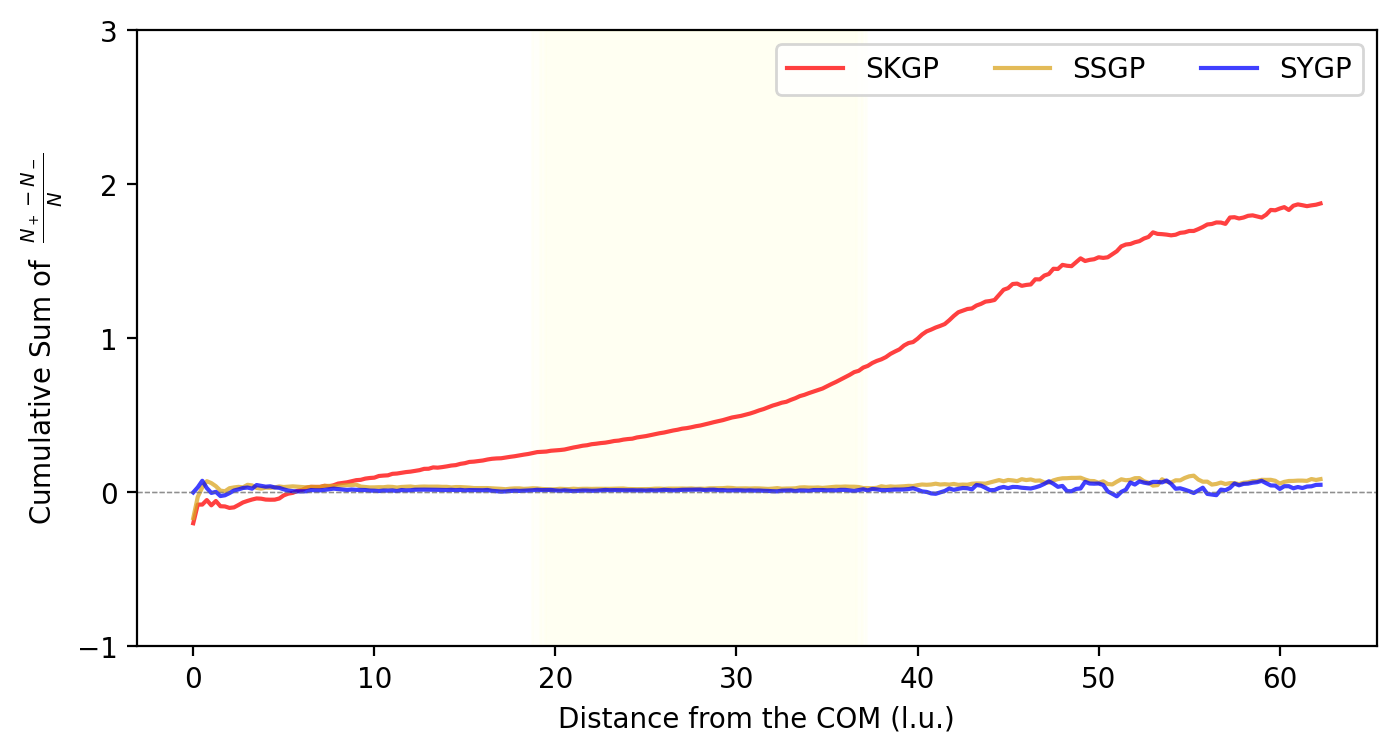

In [3]:
# Analyze the net charge across radial distances from the center of mass of the condensate.

cmap=['red','goldenrod','blue']
variants = ['SKGP', 'SSGP', 'SYGP']

plt.figure(figsize=(8,4), dpi=200)
for s in range(0,len(variants)):
    print(variants[s])
    
    # For each variant, load the radial density profiles computed for 
    # all residues, positively charged and negatively charged beads in the system 
    radial_counts = pd.read_csv('/Data/{c}_radial_counts.csv'.format(c=variants[s]))
    
    all_res = radial_counts.iloc[0, 1:]
    positive_res = radial_counts.iloc[1, 1:]
    negative_res = radial_counts.iloc[2, 1:]
    
    delta_rho = [(positive_res[x] - negative_res[x]) / all_res[x]  for x in range(0,len(all_res))]
    cumulative_sum = np.cumsum(delta_rho)
    plt.plot(radial_bins[:250], cumulative_sum[:250], linewidth=1.5, label=variants[s], c=cmap[s], alpha=0.75)
    plt.axhline(0, linewidth=0.5, alpha=0.5, c='gray', linestyle='--')
    
        
    ## PLOT INTERFACE
    comden_array = []
    for r in range(0,len(reps)):
        tmp_comden = np.loadtxt('/SimulationData/T55_{s}'.format(s=variants[s])+'/'+str(reps[r])+'/A1LCD_COMDen.dat')
        comden_array.append(tmp_comden[3])
        
    comden = np.mean(comden_array, axis=0)
    norm_den_dilute = comden / Prior_dist
    np.nan_to_num(norm_den_dilute, copy=0, nan=0.0, posinf=0.0, neginf=0.0)
    x_range_dilute, norm_den_dilute = zip(*[(x, y) for x, y in zip(radial_bins, norm_den_dilute) if not np.isnan(y) and y > 0])
    dil,dense,mid,width=conc_analytic(norm_den_dilute,x_range_dilute)
    
    plt.axvspan(mid-width, mid, alpha=0.15, color='lightyellow')

    plt.legend(ncol=3, fontsize=10)
    plt.xlabel("Distance from the COM (l.u.)")
    plt.ylabel(r'Cumulative Sum of  $\frac{N_+ - N_-}{N}$')
    plt.yticks([-1,0,1,2,3])
